[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1IBNJgRYnz0e4ZeRDw25i46rBrYl5WPq2)

# Computer Vision

Images are large grids of color values. Techniques have been developed over many years with the intention of extracting information from images. This coding challenge explains one of the most common and most basic techniques, filtering via convolution.

### An Image
![Grid](https://www.dropbox.com/s/fhq8j6oo828u03r/image%20grid.png?raw=1)

## Iteration

Iterating on an image typically involves visiting each point in the image. Images have a height and a width, so there are two dimensions to iterate over, $x$ and $y$. The order of iteration is extremely important! Different results occur depending on if the image is iterated in a row-major fashion or a column-major fashion.

![Image iteration](https://www.dropbox.com/s/qr9oditnfk8l1vo/image_iteration.png?raw=1)

## Convolution

Many image processing techniques depend on this basic building block: convolution. Image convolution involves laying the filter "on top" of the image and computing the sum of the products of the overlapping values. The resulting value is stored in a new image. The filter (or mask) is moved by one (or more) pixel(s), and the process is repeated across the entire image.


$C_{i,j} = \sum_{F_{x,y}}{ I_{i-x,j-y}F_{x,y}}$

## Filtering

Convolution is always performed with a filter, mask, or kernel: typically a $k \times k$ matrix where $k$ is odd. This gives the filter an obvious center, which is used to compute the combination of the filter with the image at each coordinate of the image.

Filters include:
* https://en.wikipedia.org/wiki/Kernel_(image_processing)
* https://en.wikipedia.org/wiki/Hessian_matrix
* https://en.wikipedia.org/wiki/Difference_of_Gaussians
* https://homepages.inf.ed.ac.uk/rbf/HIPR2/log.htm


## Rotation, Translation, and Scale Invariance

## Scale Space

A given image exists in a particular scale space - that is, the only data recorded in the image exists at each particular coordinate. Filters like those above produce interesting features only in the scale space of the original image - usually very small and uninformative to those observing the image. In order to detect features that are larger than single-pixel relationships, the image can be converted to a scale space image, or image pyramid.

### Example

Through convolution with a Gaussian kernel with $\sigma = 1/2$, followed by an image operation called subsampling, the image can be shrunk.

![Scale Space Image](https://www.dropbox.com/s/eqjbh08njtohi0l/scale_space_image.png?raw=1)


### Subsampling

Creating a new image where each pixel $p_{i,j} = f(I,i,j)$ where $f(I,i,j) = \frac{I_{2i,2j}+I_{2i+1,2j}+I_{i,2j}+I_{i,2j+1}}{4}$. This image is exactly 1/2 the size of the original image. Assuming the original image was previously smoothed by the appropriate Gaussian kernel, no useful information is lost. The new image is identical to the original image, presenting features $2x$ as large.



---



# Feature Vectors and Mapping

Finally, a set of regions discovered through a combination of the above techniques can be bagged/mapped into a group. Training algorithms then, can identify which groups of features belong to specific object classes, leading to the previous state of the art in image recognition systems. This was before Deep CNNs came into the picture – which are capable of learning the required filters themselves. Even though the recent Deep Learning advancements have changed Computer Vision dramatically, some of these basic concepts are still the same, and understanding them is crucial in understanding and building powerful Deep CNNs.


In [0]:
!pip install imageio

    100% |████████████████████████████████| 3.3MB 6.3MB/s 
  Running setup.py bdist_wheel for imageio ... - \ | / done
  Stored in directory: /root/.cache/pip/wheels/e0/43/31/605de9372ceaf657f152d3d5e82f42cf265d81db8bbe63cde1
Successfully built imageio


# Convolution with a DoG Filter

https://www.dropbox.com/s/14dbm1onz9wx2r3/all_the_things.png?raw=1

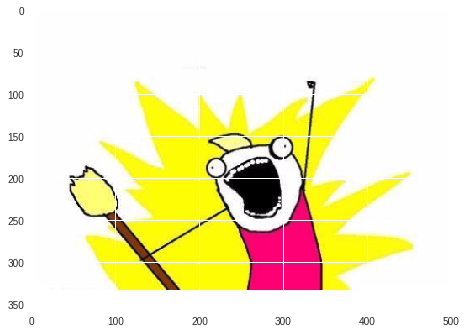

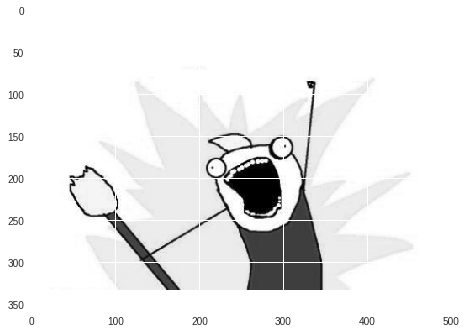

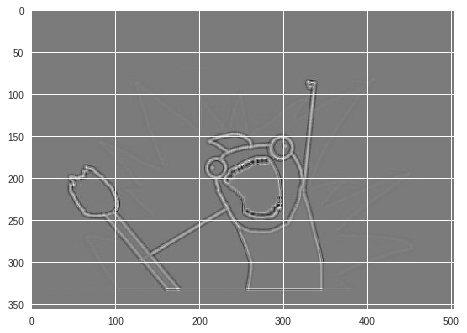

In [0]:
import numpy as np
import scipy.ndimage as nd
import imageio
from skimage import color
import matplotlib.pyplot as plt

dog_filter = np.array([[1, 1, 1, 1, 1],
                       [1, -3, -3, -3, 1],
                       [1, -3, 8, -3, 1],
                       [1, -3, -3, -3, 1],
                       [1, 1, 1, 1, 1]])

I = imageio.imread('https://www.dropbox.com/s/14dbm1onz9wx2r3/all_the_things.png?raw=1')
I_g = color.rgb2gray(I)
C = nd.convolve(I_g, dog_filter)

plt.imshow(I)
plt.show()
plt.imshow(I_g, cmap='gray')
plt.show()
plt.imshow(C, cmap='gray');

# Convolution + Subsampling

### Create a function for subsampling

$p_{i,j} = f(I,i,j)$ where $f(I,i,j) = \frac{I_{2i,2j}+I_{2i+1,2j}+I_{2i,2j+1}+I_{2i+1,2j+1}}{4}$

In [0]:
def sub_sample_manual(I):  
  if I.shape[0]%2 != 0:
    I = np.row_stack((I, np.zeros_like(I[-1, :])))
    
  if I.shape[1]%2 != 0:
    I = np.column_stack((I, np.zeros_like(I[:, -1])))
    
  width = int(I.shape[0]/2)
  height = int(I.shape[1]/2)
  I_sub = np.zeros(shape=(width, height))
  for i in range(width):
    for j in range(height):
      I_sub[i, j] = (I[2*i, 2*j] + I[2*i+1, 2*j] + I[2*i, 2*j+1] + I[2*i+1, 2*j+1])/4
  
  return I_sub

Alternate (using library)

In [0]:
from skimage.transform import downscale_local_mean

def sub_sample_lib(I):
  return downscale_local_mean(I, (2, 2))

### Image Pyramid

shape: (356, 503)
number_of_scale_spaces: 8



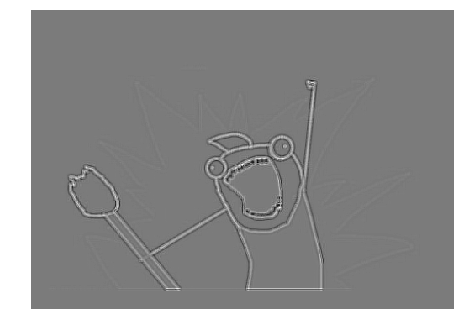

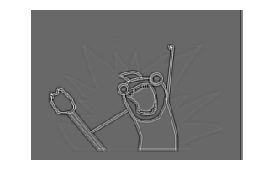

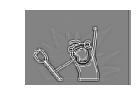

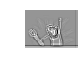

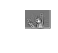

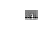

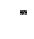

In [0]:
from scipy.ndimage import gaussian_filter

I = imageio.imread('https://www.dropbox.com/s/14dbm1onz9wx2r3/all_the_things.png?raw=1')
I_g = color.rgb2gray(I)

print("shape:", I_g.shape)
number_of_scale_spaces = int(np.log2(min(I_g.shape[0], I_g.shape[1])))
print("number_of_scale_spaces:", number_of_scale_spaces)
print()

convolutions = []
for i in range(number_of_scale_spaces-1):
  scale = np.power(2, i)
  if i > 0:
    I_g_gaussian = gaussian_filter(I_g, sigma=1/scale)
    I_g = sub_sample_manual(I_g_gaussian)  
  C = nd.convolve(I_g, dog_filter)
  convolutions.append((scale, C))

# display the image pyramid with matplotlib
for scale, C in convolutions:
  plt.figure(figsize=(8/scale, 5.5/scale))
  plt.axis('off')
  plt.imshow(C, cmap='gray')
  plt.show()